In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import v2

In [2]:
# load in data from torchvision datasets

batch_size=256

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)


In [3]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512,512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512,512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512,10),
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}")
model = NeuralNetwork()
model.to(device)

Using mps


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [4]:
def move_to_GPU(a, b):
  return a.to(device), b.to(device)

In [5]:
def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)  # for summaries

  # Set model to training mode
  model.train()

  train_loss, correct_predictions = 0, 0

  # Loop over the dataset and run a gd update
  for batch, (X, y) in enumerate(dataloader):

    # MOVE DATA TO GPU
    X, y = move_to_GPU(X, y)

    # FORWARD PASS
    output = model(X)
    loss = loss_fn(output, y)

    # BACKWARD PASS
    # compute gradients and perform gd update
    loss.backward()
    optimizer.step()

    # zero out the gradients in the optimizer after updating
    optimizer.zero_grad()

    train_loss += loss
    correct_predictions += (output.argmax(1) == y).type(torch.float).sum().item()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * batch_size + len(X)
      print(f"Loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

  train_loss /= len(dataloader)
  correct_predictions /= size

  print(f"Training Error: \nAccuracy: {correct_predictions * 100:>0.1f}%, Avg. loss: {train_loss:>8f} \n")

  return train_loss.item()

def test_loop(dataloader, model, loss_fn):
  # Set model to eval mode
  model.eval()

  size = len(dataloader.dataset)  # for summaries

  num_batches = len(dataloader)

  # scalar loss and accuracy measures
  test_loss, correct_predictions = 0, 0

  # save computation --> don't compute gradients
  with torch.no_grad():
    for X, y in dataloader:

      # Move the data to GPU
      X, y = move_to_GPU(X, y)
      output = model(X)
      test_loss += loss_fn(output, y)
      correct_predictions += (output.argmax(1) == y).type(torch.float).sum().item()

  # print accuracy and scalar loss at the end
  test_loss /= num_batches
  correct_predictions /= size
  print(f"Test Error: \nAccuracy: {correct_predictions * 100:>0.1f}%, Avg. loss: {test_loss:>8f} \n")

  return test_loss.item()


In [6]:
# Initialize hyperparameters

learning_rate = 1e-3
epochs = 20

In [7]:
# define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
test_losses = []

# train/optimize the model for each epoch
for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-----------------------------")
  train_l = train_loop(train_dataloader, model, loss_fn, optimizer)
  test_l = test_loop(test_dataloader, model, loss_fn)
  train_losses.append(train_l)
  test_losses.append(test_l)
print("Training Complete.")

Epoch 1
-----------------------------


/Users/agoth/Desktop/self-study/deep-learning/dl-book/udl-notebooks/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Loss: 2.304451 [  256/60000]
Loss: 0.632592 [25856/60000]
Loss: 0.410421 [51456/60000]
Training Error: 
Accuracy: 77.6%, Avg. loss: 0.608738 

Test Error: 
Accuracy: 80.2%, Avg. loss: 0.502673 

Epoch 2
-----------------------------
Loss: 0.400715 [  256/60000]
Loss: 0.489882 [25856/60000]
Loss: 0.346690 [51456/60000]
Training Error: 
Accuracy: 85.5%, Avg. loss: 0.396658 

Test Error: 
Accuracy: 85.9%, Avg. loss: 0.397950 

Epoch 3
-----------------------------
Loss: 0.326766 [  256/60000]
Loss: 0.361676 [25856/60000]
Loss: 0.395203 [51456/60000]
Training Error: 
Accuracy: 86.8%, Avg. loss: 0.356463 

Test Error: 
Accuracy: 86.3%, Avg. loss: 0.373199 

Epoch 4
-----------------------------
Loss: 0.349523 [  256/60000]
Loss: 0.275272 [25856/60000]
Loss: 0.349647 [51456/60000]
Training Error: 
Accuracy: 87.8%, Avg. loss: 0.333588 

Test Error: 
Accuracy: 86.7%, Avg. loss: 0.357067 

Epoch 5
-----------------------------
Loss: 0.352568 [  256/60000]
Loss: 0.299577 [25856/60000]
Loss: 0.37

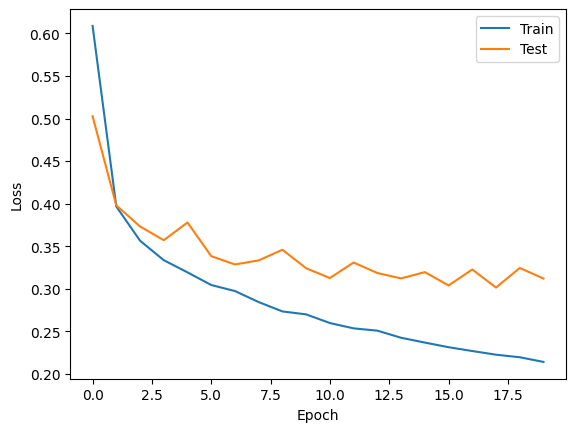

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train_losses, label="Train")
ax.plot(test_losses, label="Test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()